# **Final Project - From Signals to Feelings: Predicting Emotion with Machine Learning**
## Gabriel Pereira and Deng Arguer Bul
## May 4th, 2026
## DSC 101 - Dr. Rimal

# **Abstract**

This study investigates whether physiological signals can be used predict emotional states. Understanding how emotions are reflected in the body is vital as electrodermal activity, heart rate, and movement can provide significant insight on emotional conditions. As the use of wearable devices is rapidly growing, there is an increase in interest in using biometric and physiological data to detect emotion states.  

Initially, this project aimed to examine how external factors such as music condition and task difficulty could predict stress levels during a working memory task. However, due to difficulty in aligning behavioral variables with phsyiological data and missing values along the dataset, this approach was not realistic. As a result, we decided to shift towards using the physiolgoical signals to predict emotional states.

The objective of this project is to determine if physiological features like electrodermal activity (EDA), temperature, heart rate (HR), blood volume pulse (BVP), interbeat interval (IBI), and accelerometer data (ACC), can be used to predict emotional state. Emotional responses were categorized into two different classes, emotional which contained Angry, Sad, and Happy emotion data and emotionless which contained neutral emotion data.

The dataset was cleaned, aligned, and processed without including missing values. This ensured that only valid and significant observations were included. A logistic regression model was then constructed to predict emotional states based on the selected physiological features.
The dataset was carefully cleaned, processed, and merged across multiple modalities. A regression-based modeling approach was then applied to analyze the relationship between input features and stress levels.

The findings suggest that certain phsyiological signals, specifcially electrodermal activity and temperature, are better at distinguishing between emotional and emotionless states. However, other features like BVP, IBI, and accelerometer data lack ability to predict. This all shows the potential that wearable devices have on collecting physiological data to detect emotion. If further developed, these types of models could be used in the real world such as mental health monitoring and personalized wellness systems.

# **About the Dataset**

The dataset used in this project is titled:

“A Multimodal Dataset for Investigating Working Memory in Presence of Music” Published on PhysioNet (Version 1.0.0, 2025)

Citation: Khazaei, S., Parshi, S., Alam, S., Amin, M. R., & Faghih, R. T. (2025). A Multimodal Dataset for Investigating Working Memory in Presence of Music. PhysioNet.

The dataset consists of multimodal physiological and behavioral data that was collected to study emotional responses. The data was collected from a controlled experiment where subjects were monitored using wearable sensors and facial recognition software while they engaged in tasks that were designed to cause different emotions. Physiological data was collected by using Empatica wearable devices, which measured signals like electrodermal activity (EDA), temperature, heart rate (HR), blood volume pulse (BVP), interbeat interval (IBI), and accelerometer data (ACC). Furthermore, facial expressions were detected by using FaceReader software.

The dataset was compiled by merging data from the Empatica sensor recordings and FaceReader files. These two datasets were aligend based on time to ensure that the signals matched with the correct emotion. The final dataset used in our analysis includes observations from several different subjects and contains only rows with valid emotional state as rows with missing or unkown emotions were dropped during preprocessing. 

The final dataset is made up of 1,421 observations with the following variables:

+ **Time**(float): Timestamp representing the alligned time in seconds
+ **Empatica_EDA** (float): Data from the electrodermal activity sensor measured in microsiemens (μS), indicating physiological stimulation
+ **Empatica_TEMP** (float): Skin temperature measured in degrees celsius
+ **Empatica_HR** (float): Heart rate measured in beats per minute
+ **Empatica_BVP** (float): Blood volume pulse signal
+ **Empatica_IBI** (float): Interbeat interval measured in seconds, representing the time between heartbeats
+ **ACC_X, ACC_Y, ACC_Z** (float): Accelerometer data representing movement along the three axes
+ **Emotion (int)**: Target variable, 0 = emotionles and 1 = emotional
+ **subject_id** (object): Differentiates between each subject

This dataset gives a layout of the physiological repsonses and allows us to perform and analysis of how the signals can be used to predict emotional states. 

# **Data Cleaning and Preprocessing**

In [42]:
# Importing Libraries 
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Making Paths for Data to be Read
BASE_PATH = "/Users/gabrielpereira/Downloads/music_data"
FACE_BASE = os.path.join(BASE_PATH, "Face_reader_data")
EMP_BASE = os.path.join(BASE_PATH, "Empatica_data")

In [49]:
def load_raw_subject_files(sub):
    '''
    Input:
    The input here is sub. This is the subject ID that is
    used to locate the specific subject's data files.

    Task:
    This function loads the raw physiological data and facial
    data for a given subject. It also searches in the appropriate 
    directories for FaceReader, which is facial expression, and
    Empatica which is wearable sensors, for the data files. 
    From there, it reads them into pandas DataFrames,
    organizes them into a dictionary. It deals with al the sensor types, 
    which are EDA, temperature, heart rate, BVP, IBI, and accelerometer
    data.

    Output:
    The output is the dictionary, raw_data. It contains the subject's
    data. Each of the keys in it correspond to a specific data source. 
    Each value is a pandas dataframe or list of dataframes.
    '''
    raw_data = {}
    
    # Loads FaceReader Data
    face_folder = f"{FACE_BASE}/subject_{sub}"
    if os.path.exists(face_folder):
        state_files = [f for f in os.listdir(face_folder) if 'video_state.txt' in f]
        raw_data['face'] = [
            pd.read_csv(f"{face_folder}/{f}", sep='\t', skiprows=4)
            for f in state_files
        ]

    # Loads Empatica Data 
    emp_folder = f"{EMP_BASE}/Subject_{sub}"
    if os.path.exists(emp_folder):
        sensors = ['EDA', 'TEMP', 'HR', 'BVP', 'IBI', 'ACC']
        
        for s in sensors:
            f_path = f"{emp_folder}/Subject{sub}_{s}.csv"
            if os.path.exists(f_path):
                
                if s == 'ACC':
                    # ACC has 3 columns (x, y, z)
                    raw_data['emp_acc'] = pd.read_csv(
                        f_path, skiprows=2, header=None,
                        names=['ACC_X', 'ACC_Y', 'ACC_Z']
                    )
                else:
                    raw_data[f'emp_{s.lower()}'] = pd.read_csv(
                        f_path, skiprows=2, header=None,
                        names=[f'Empatica_{s}']
                    )
                
    return raw_data

In [141]:
def clean_and_align_subject(sub, raw):
    '''
    Input: 
    The inputs are sub which is subject ID 
    and raw which is a dictionary of raw data 
    returned from load_raw_subject_files(). It 
    contains Empatica sensor data and FaceReader 
    data.

    Task:
    This function cleans and alligns the physiological
    and emotion data for each subject onto a common 
    time axis. It also uses EDA as the base timeline
    and syncs the other signals using time merging.

    It also processes facial emotion data by doing the following:
    1) Cleaning and standardizing emotion labels
    2) Filtering valid emotions (happy, sad, angry, and neutral)
    3) Converting emotions into binary categories (Emotional and Emotionless)
    4) Aligning the emotion timestamps with physiological data

    It then removes the rows with missing emotion labels to make 
    sure the dataset is clean. 

    Output: 
    The output is df. It is the cleaned and time aligned dataset 
    that contains all the synced physiological signals and their emotion labels 
    for each subject. 
    '''

    
    # Base timeline (EDA)
    if 'emp_eda' not in raw:
        return pd.DataFrame()
        
    df = raw['emp_eda'].copy()
    df['Time'] = np.arange(len(df)) * 0.25
    df = df.set_index('Time').sort_index()
    
    # Merges the Empatica signals
    for key, freq in [
        ('emp_temp', 4),
        ('emp_hr', 1),
        ('emp_bvp', 64),   # BVP high frequency
        ('emp_ibi', 1)     # IBI irregular but treat approx
    ]:
        if key in raw:
            data = raw[key]
            data.index = np.arange(len(data)) / freq
            data.index.name = 'Time'
            
            df = pd.merge_asof(
                df,
                data.sort_index(),
                left_index=True,
                right_index=True,
                direction='nearest',
                tolerance=0.5
            )

    # Handle ACC separately (3 columns)
    if 'emp_acc' in raw:
        acc = raw['emp_acc']
        acc.index = np.arange(len(acc)) / 32  # ACC is ~32Hz
        acc.index.name = 'Time'

        df = pd.merge_asof(
            df,
            acc.sort_index(),
            left_index=True,
            right_index=True,
            direction='nearest',
            tolerance=0.5
        )

    # Emotion Processing
    if 'face' in raw:
        emo_list = []
        
        for f in raw['face']:
            f.columns = ['Video_Time', 'Emotion']
            
            f['Emotion'] = (
                f['Emotion']
                .astype(str)
                .str.strip()
                .str.lower()
            )
            
            valid = ['happy', 'sad', 'angry', 'neutral']
            f = f[f['Emotion'].isin(valid)].copy()
            
            f['Emotion'] = f['Emotion'].replace({
                'happy': 'Emotional',
                'sad': 'Emotional',
                'angry': 'Emotional',
                'neutral': 'Emotionless'
            })
            
            f['Sec'] = pd.to_timedelta(f['Video_Time']).dt.total_seconds()
            emo_list.append(f[['Sec', 'Emotion']])
        
        if emo_list:
            combined = (
                pd.concat(emo_list)
                .sort_values('Sec')
                .drop_duplicates('Sec')
                .rename(columns={'Sec': 'Time'})
                .set_index('Time')
                .sort_index()
            )
            
            df = pd.merge_asof(
                df,
                combined,
                left_index=True,
                right_index=True,
                direction='nearest',
                tolerance=0.25
            )

    # Drops Missing Values in Emotion (no filling)
    if 'Emotion' in df.columns:
        df = df.dropna(subset=['Emotion'])
    else:
        return pd.DataFrame()
        
    return df

In [143]:
subjects = ['3F', '4F', '6M', '8M', '11F']
all_dfs = []

for sub in subjects:
    '''
    Input:
    The input is a list of subject IDs and the functions.

    Task:
    This loops through each subject, loads their physiological 
    and facial data, and applies cleaning and time allignment.
    For each subject, the dataset is store and then labeled with
    the subject ID. All the subjects are then combined into one
    dataset. Then, the emotion labels are converted from categorical
    values (Emotionless and Emotional) to numerical values (0 and 1) 
    to be used in modeling.
    
    Outputs:
    The outputs are final_data which is the combined dataset which contains 
    all subjects with the cleaned and alligned signals and emotion label.
    '''
    
    raw = load_raw_subject_files(sub)
    aligned_df = clean_and_align_subject(sub, raw)
    
    if not aligned_df.empty:
        aligned_df['subject_id'] = sub
        all_dfs.append(aligned_df)

if all_dfs:
    final_data = pd.concat(all_dfs).reset_index()
    #Maps Emotionless to 0 and Emotional to 1
    final_data['Emotion'] = final_data['Emotion'].map({
        'Emotionless': 0,
        'Emotional': 1
    })

In [124]:
#Shows the distribution of emotional (1) and emotionless (0) classes
print(final_data['Emotion'].value_counts())

Emotion
0    835
1    586
Name: count, dtype: int64


In [52]:
final_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1421 entries, 0 to 1420
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Time           1421 non-null   float64
 1   Empatica_EDA   1421 non-null   float64
 2   Empatica_TEMP  1421 non-null   float64
 3   Empatica_HR    1421 non-null   float64
 4   Empatica_BVP   1421 non-null   float64
 5   Empatica_IBI   1287 non-null   float64
 6   ACC_X          1421 non-null   int64  
 7   ACC_Y          1421 non-null   int64  
 8   ACC_Z          1421 non-null   int64  
 9   Emotion        1421 non-null   int64  
 10  subject_id     1421 non-null   object 
dtypes: float64(6), int64(4), object(1)
memory usage: 122.2+ KB


In [98]:
final_data.head()

,Time,Empatica_EDA,Empatica_TEMP,Empatica_HR,Empatica_BVP,Empatica_IBI,ACC_X,ACC_Y,ACC_Z,Emotion,subject_id
0,1.00,0.019221,23.67,87.50,98.42,0.796911,24,52,-4,0,3F
1,1.25,0.019221,23.67,87.50,231.82,0.796911,18,52,-36,0,3F
2,6.00,0.015377,25.41,93.86,-50.22,0.843789,-13,-5,62,1,3F
3,6.25,0.015377,25.41,93.86,-106.64,0.843789,-11,2,64,1,3F
4,11.75,0.010251,25.67,84.31,19.49,0.796911,7,-10,65,0,3F


In [90]:
final_data.shape

(1287, 11)

# Visualizations

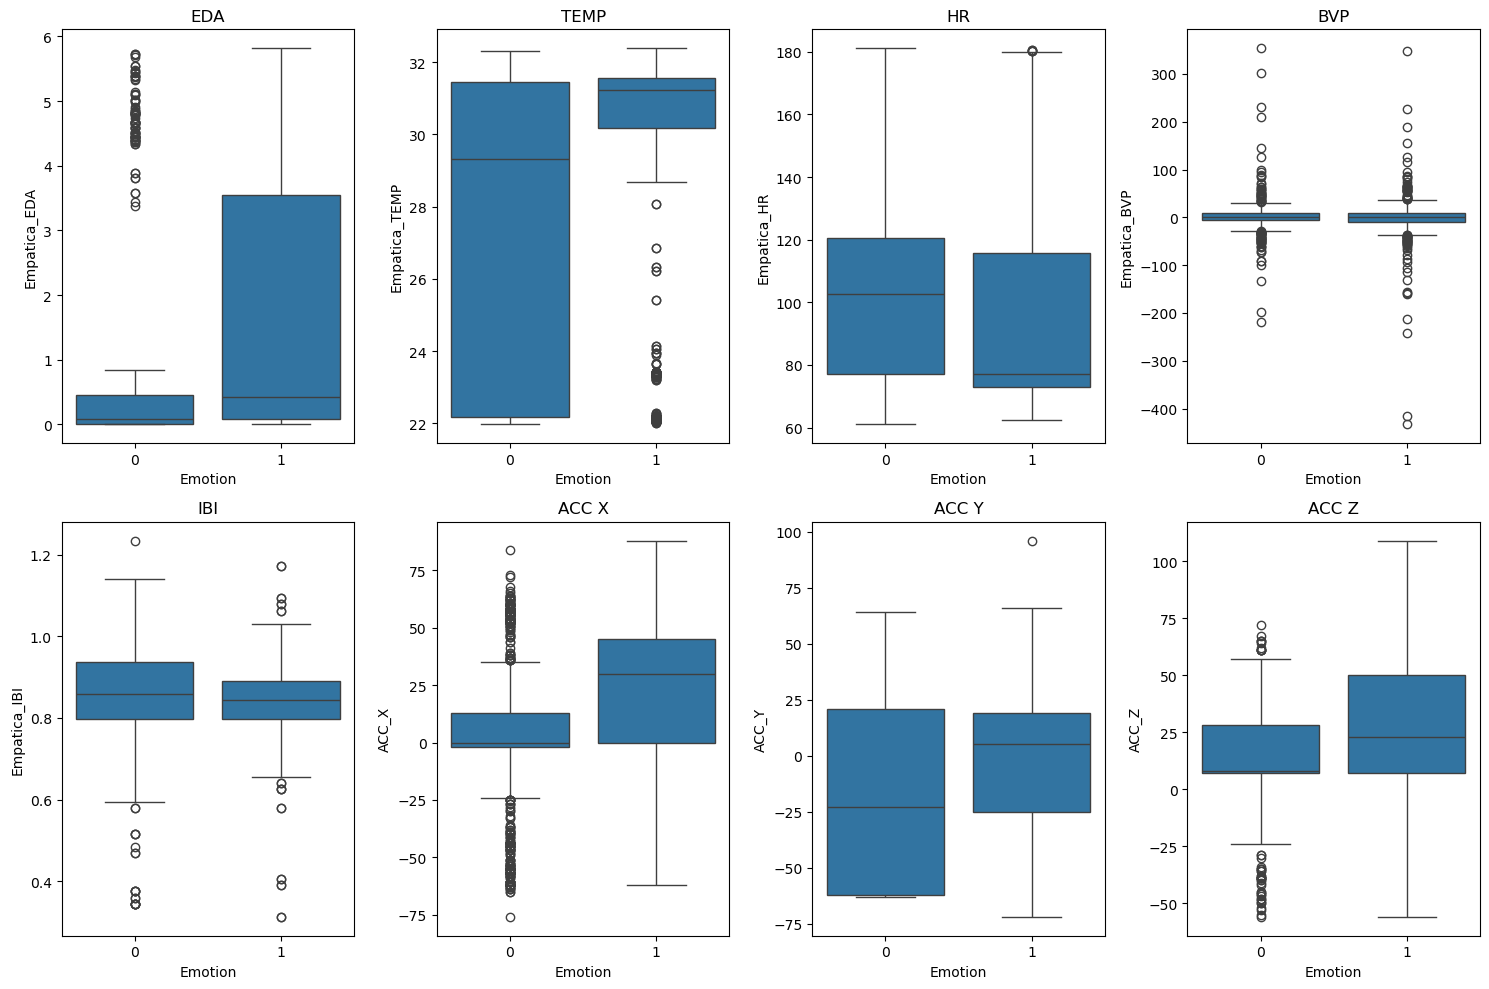

In [55]:
plt.figure(figsize=(15, 10))

# Row 1 
plt.subplot(2, 4, 1)
sns.boxplot(data=final_data, x='Emotion', y='Empatica_EDA')
plt.title('EDA')

plt.subplot(2, 4, 2)
sns.boxplot(data=final_data, x='Emotion', y='Empatica_TEMP')
plt.title('TEMP')

plt.subplot(2, 4, 3)
sns.boxplot(data=final_data, x='Emotion', y='Empatica_HR')
plt.title('HR')

plt.subplot(2, 4, 4)
sns.boxplot(data=final_data, x='Emotion', y='Empatica_BVP')
plt.title('BVP')

#  Row 2 
plt.subplot(2, 4, 5)
sns.boxplot(data=final_data, x='Emotion', y='Empatica_IBI')
plt.title('IBI')

plt.subplot(2, 4, 6)
sns.boxplot(data=final_data, x='Emotion', y='ACC_X')
plt.title('ACC X')

plt.subplot(2, 4, 7)
sns.boxplot(data=final_data, x='Emotion', y='ACC_Y')
plt.title('ACC Y')

plt.subplot(2, 4, 8)
sns.boxplot(data=final_data, x='Emotion', y='ACC_Z')
plt.title('ACC Z')

plt.tight_layout()
plt.show()

These boxplots show clear differences between emotional and emotionless states across the different signals. In terms of electrodermal activity (EDA), the emotional states (1) have a much wider spread, with values going all the way up to around 5–6. However, for the emotionless states (0), the values are tightly concentrated near 0 with only a few higher outliers. This indicates that emotional states are associated with higher and more variable electrodermal activity, making EDA a strong distinguishing feature. For temperature, emotional states have a higher median of around 31 degrees Celsius, while the emotionless states have a median of around 29–30 degrees Celsius. Heart rate shows the weakest differences, as emotionless states have a slightly higher median of around 100 BPM, while the emotional states have a median of around 75–80 BPM. However, both groups have a very wide range of heart rate values from around 60–180 BPM, which results in heavy overlap. For blood volume pulse (BVP), both emotional and emotionless states show a large amount of variability and outliers. There is no clear difference in the median or spread between the two groups, suggesting that BVP is not a strong indicator of emotion. Similarly, the interbeat interval (IBI) shows little difference, as both groups are clustered around similar values of approximately 0.8 to 0.9. For the accelerometer data, ACC X, ACC Y, and ACC Z all display high variability and wide ranges of values for both emotional and emotionless states. Even though there are slight shifts in medians, specifically in ACC X and ACC Z where the emotional states tend to show slightly higher values, the distributions still show a lot of overlap. This suggests that accelerometer data can capture more variability but does not provide strong separation between emotional and emotionless states. Overall, EDA appears to provide the strongest separation between emotional and emotionless states, while temperature, heart rate, BVP, IBI, and accelerometer data show significant overlap between the two groups, indicating that these features may not be as effective in predicting emotion.

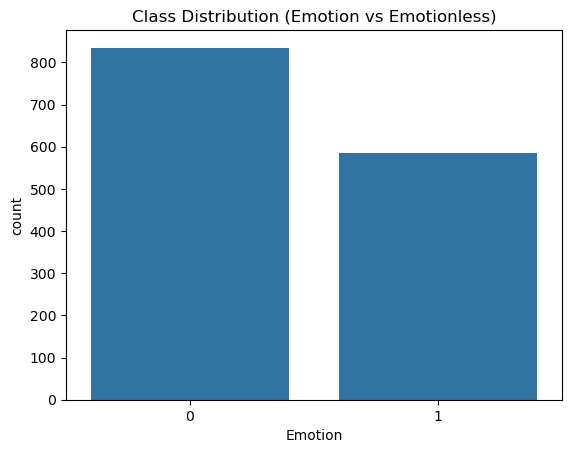

In [56]:
sns.countplot(data=final_data, x='Emotion')
plt.title("Class Distribution (Emotion vs Emotionless)")
plt.show()

This countplot shows that the dataset contains more emotionless (0) observartions than emotional (1) observations. Particularly, the emotionless class appears to have around 800+ samples, while the emotional class seems to have around 550-600 samples. This shows that there is a moderate class imbalance, where the emotionaless class is more frequently represented than the emotional class. Even though this imbalance is not extreme, it may still influence how patterns are learned from the data. This difference in counts suggests that any analysis or modeling of this data should take into account that emotionless states are more prevalent in the dataset. This may reflect how the experiment was ran or suggest that particpatns often remained in a neutral state rather than experiencing emotional responses. 

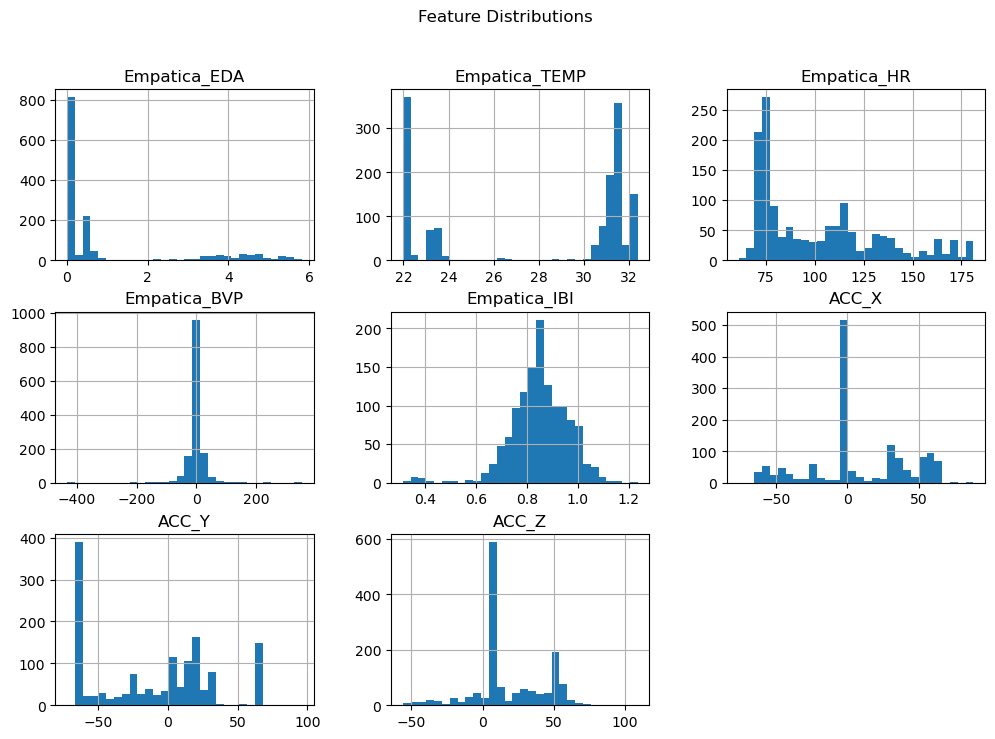

In [57]:
features = [
    'Empatica_EDA',
    'Empatica_TEMP',
    'Empatica_HR',
    'Empatica_BVP',
    'Empatica_IBI',
    'ACC_X',
    'ACC_Y',
    'ACC_Z'
]

final_data[features].hist(bins=30, figsize=(12, 8))
plt.suptitle("Feature Distributions")
plt.show()

These histograms show the overall distribution of each physiological feature, showing patterns in the spread of the data. For Empatica_EDA, most of the values are heavily concentrated near 0, heavily skewed to the right with a tail extending up to around 5 to 6. This suggests that low levels of electrodermal activty are most common, wih occasional spikes representing periods of higher physiological activity. For Empatica_TEMP, the distribution seems to be bimodal with one cluster around 22-23 degrees celsius and another more dominant cluster at around 30-32 degrees celsius. This inidcates that temperature measurements typically fall into two different ranges, which may reflect different conditions or phases of the experiments. For the Empatica_HR, the distribution appears to be much more spread out, with values ranging from 60 to around 180 BPM. Most of the values seem to be concentrated at around 65-80 BPM, with smaller peaks at in higher values. This suggests that heart rate varies across the observations, with resting heart rate being the most common. For Empatica_BVP, the distribution is concentrated around 0 but with some extreme values in both the positive and negative direction. This indicates that most BVP readings are stable, but there are occasional fluctuations which may be due to movement or sensor noise. For Empatica_IBI, the distribution is rather normally shaped with a center around 0.8 to 0.9 and far less variation than the otehr features, suggesting that there are more consistent measurements. Furthermore, for the accelerometer data, ACC_X, ACC_Y, and ACC_Z show wide ranges of values with spikes at certain points, typically around 0 and higher values, suggesting that there is high variability in movement. Overall, the features show non-normal distributoins, with skewness and multiple peaks. This shows that there is alot of variability in the physiological responses, suggesting that the different signals may capture different aspects of physiological state.

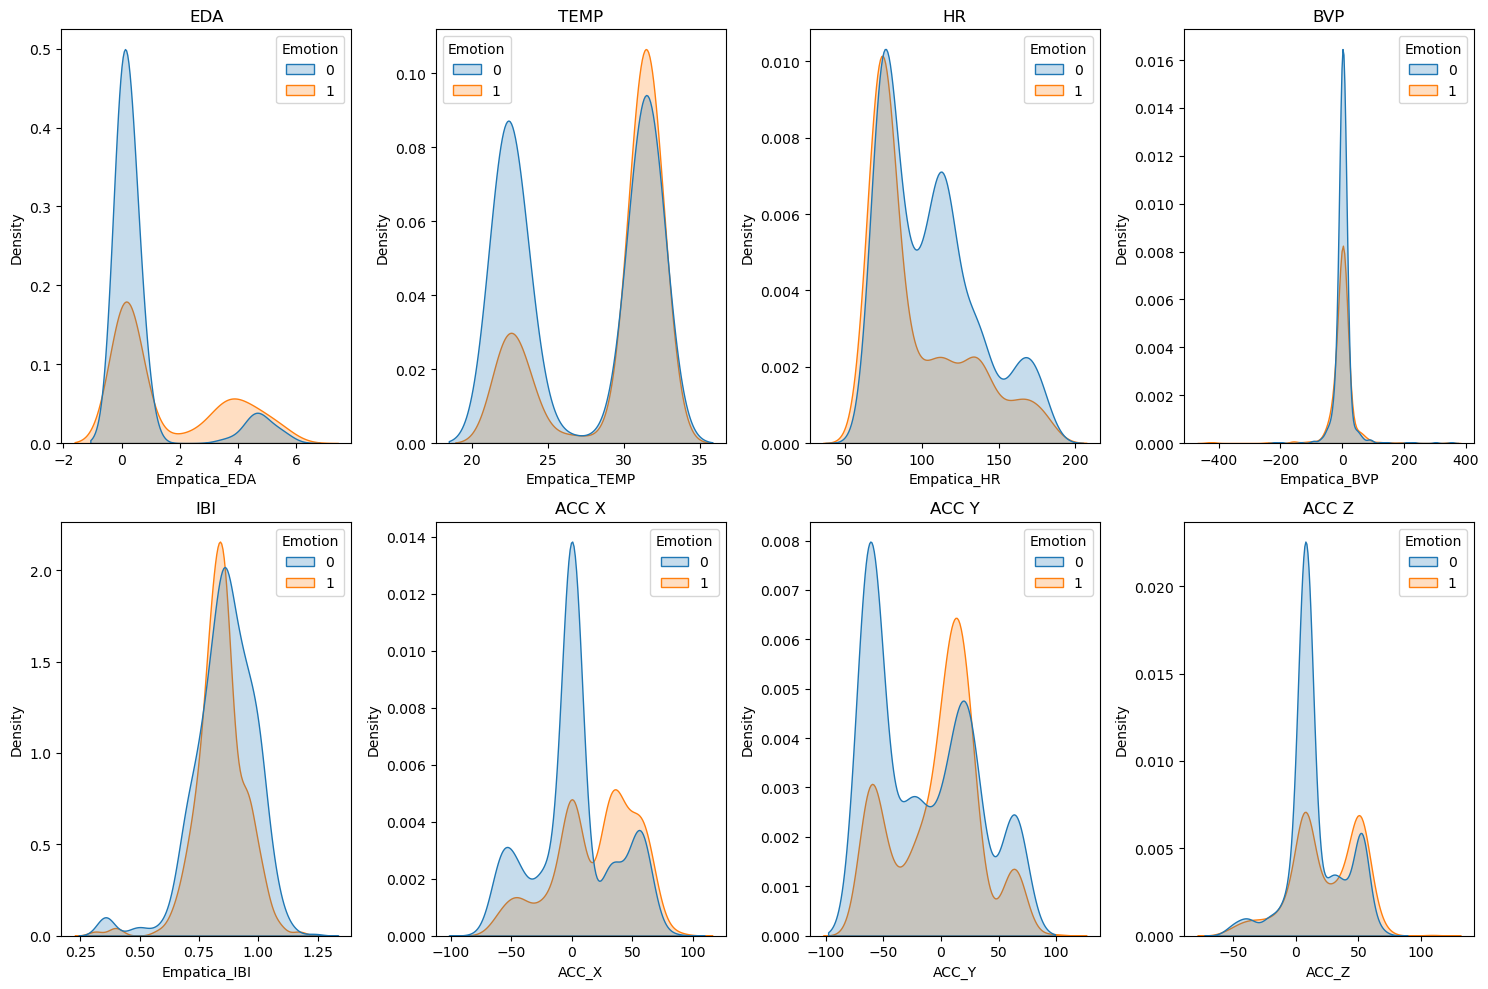

In [63]:
plt.figure(figsize=(15, 10))


plt.subplot(2, 4, 1)
sns.kdeplot(data=final_data, x='Empatica_EDA', hue='Emotion', fill=True)
plt.title('EDA')

plt.subplot(2, 4, 2)
sns.kdeplot(data=final_data, x='Empatica_TEMP', hue='Emotion', fill=True)
plt.title('TEMP')

plt.subplot(2, 4, 3)
sns.kdeplot(data=final_data, x='Empatica_HR', hue='Emotion', fill=True)
plt.title('HR')

plt.subplot(2, 4, 4)
sns.kdeplot(data=final_data, x='Empatica_BVP', hue='Emotion', fill=True)
plt.title('BVP')


plt.subplot(2, 4, 5)
sns.kdeplot(data=final_data, x='Empatica_IBI', hue='Emotion', fill=True)
plt.title('IBI')

plt.subplot(2, 4, 6)
sns.kdeplot(data=final_data, x='ACC_X', hue='Emotion', fill=True)
plt.title('ACC X')

plt.subplot(2, 4, 7)
sns.kdeplot(data=final_data, x='ACC_Y', hue='Emotion', fill=True)
plt.title('ACC Y')

plt.subplot(2, 4, 8)
sns.kdeplot(data=final_data, x='ACC_Z', hue='Emotion', fill=True)
plt.title('ACC Z')

plt.tight_layout()
plt.show()

These KDE plots compare the distribution of each phsyiological feature between emotionless (0) and emotional (1) states. By doing this, they are able to show how much the two groups overlap and where they differ in each  feature.

For EDA, there is a noticeable shift between the emotional and emotionless groups. The emotionless values are tightly concentrated around 0, while the emotional states have a second peak at higher values of around 3-5, indicating more electrodermal activity. This suggests that EDA can provide a strong separation between the two groups.  

For temperature, both of the groups show similar bimodal patterns. However, the emotional group is more concentrated in the higher range at around 30-32 degrees celsius and the emotionless group has more density in the lower range at around 22-24 degrees celsius. This indicates that there is some separation, but still a general overlap.

For heart rate, the two distributions show a significant amount of overlap. The emotionless group show a slighlty higher density at higher heart rates, while the emotional group is more concentrated at lower values. However, there is overlap across the full range of values which suggests there is weak separation.

For BVP, both groups are almost identical with a sharp peak at around 0 and long tails. This indicates that BVP does not significantly distinguish between emotional and emotionless states.

For IBI, both groups show a similar bell shape distribution with a center at around 0.8 to 0.9, with a significant amount of overlap. This suggests that there is a very little difference between the two groups.

For the accelerometer data, ACC X, ACC Y, ACC Z, all three axes show wide distributions with significant overlap. There are slight shifts in where the emotional group has more density, mostly in ACC Y and ACC Z. However, the overlap in the groups is still very significant. Thus, indicating that movement related features bring in varaiability but do not distinguish emotional states.

Overall, EDA shows the strongest differences between emotional and emotionless states. However, heart rate, BVP, IBI, temperature, and accelerometer data show significant overlap which suggests that they are not very effective and need to be combined with other signals to improve effectiveness. 

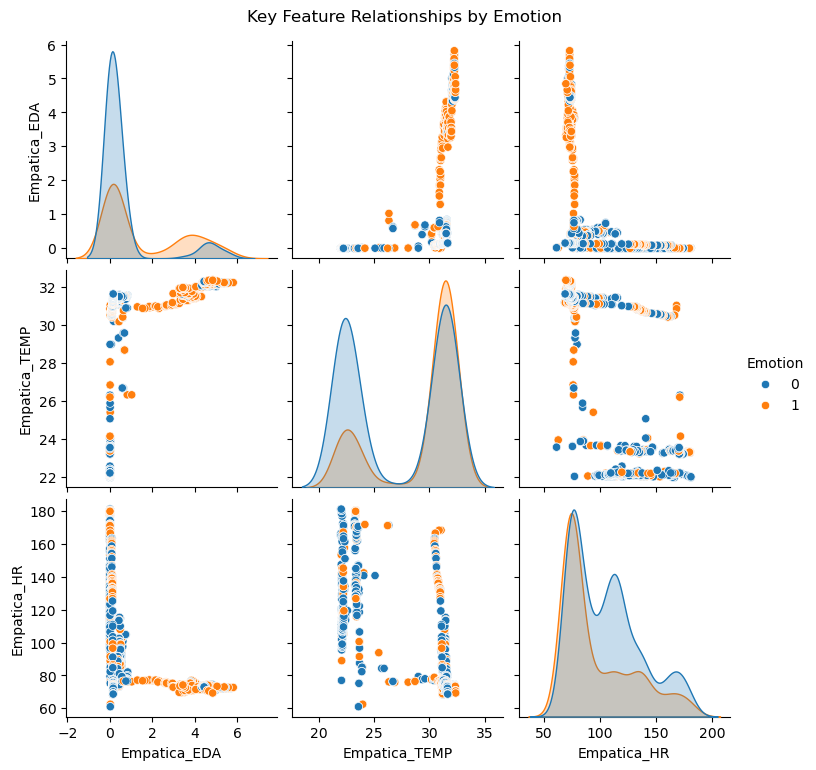

In [65]:
sns.pairplot(
    final_data,
    vars=['Empatica_EDA', 'Empatica_TEMP', 'Empatica_HR'],
    hue='Emotion',
    diag_kind='kde'
)
plt.suptitle("Key Feature Relationships by Emotion", y=1.02)
plt.show()

This pairplot provides a visualization as to how key features like EDA, temperature, and heart rate relate to each other across emotional and emotionless states. These variables were selected for this pair plot as they showed the most noticeable patterns and separation in earlier visualizations, while the other features like BVP, IBI, and accelormeter data had heavy overlap and lacked distinction amongst the classes. 

For EDA, the distribution plot shows a strong distinction as emotionless values are clustered near 0 and emotional values reach much higher levels. This reinforces the notion that EDA is a strong indicator of emotion. In the scatterplots higher EDA values are generally associated with emotional states which further supports this idea. 

For temperature, the disttributions remain bimodal, but emotional states are more concentrated at higher temperatures of around 22-24 degrees celsius. The scatterplots show a slight upward trend between EDA and temperature for emotional states. This suggests that higher electrodermal activity may be associated with higher temperature, but there is still noticeable overlap. 

For heart rate, the distributions of emotional and emotionless groups overlap, indicating little separation. The scatterplots show that heart rate lacks a strong relationship with EDA or temperature, as both groups are spread across a wide range of values.

Overall, the pairplot confirms thats EDA is the most informative feature, as it shows distinct separation between the two different groups. Temperature providces some distinction, while heart rate shows significant overlap. 

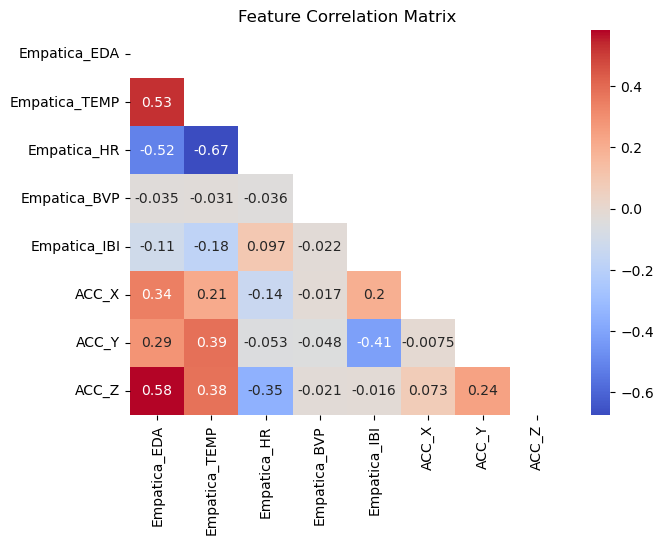

In [134]:
corr_matrix = final_data[features].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(7, 5))

sns.heatmap(corr_matrix, annot=True,
            mask=mask, cmap='coolwarm')

plt.title("Feature Correlation Matrix")
plt.show()

This correlation matrix shows the strength of relationships between the different physiological features. The strongest relationships seem to be among the main physiological features. EDA and temperature have a moderate positive correlation of around 0.53. This suggests that as temperature increases, electrodermal activity increases. On the other hand, heart rate has a strong negative relationship with both temperature and EDA, being -0.67 and -0.52, respectively. This indicates that higher heart rate values are generally associated with lower electrodermal activity and temperature levels. These relationships suggest that electrodermal activity and temperature may capture similar aspects of physiological stimulation.

BVP shows close to no correlation with any other variable, as it has values very close to zero across the entire correlation matrix. This indicates that BVP does not have a meaningful linear relationship with the other variables, suggesting that it does not contribute strongly to predicting emotional state. Similarly, IBI generally shows very weak correlations, except for a moderate negative relationship with ACC_Y of -0.41.

For the accelerometer data, ACC_X, ACC_Y, and ACC_Z show moderate positive correlations with electrodermal activity and temperature. Specifically, ACC_Z has a correlation of 0.58 with EDA, indicating that increased movement in the Z direction may be associated with increased physiological stimulation. However, the relationships between the accelerometer data themselves are pretty weak, suggesting that they show different directions of movement.

Overall, this correlation matrix shows that EDA and temperature are moderately related and may capture similar physiological stimulation, while heart rate has a negative effect on EDA and temperature. However, BVP and IBI have little to no relationships, and the accelerometer data have some variability but do not have the strongest relationships with the other signals. This all suggests that EDA and temperature are the best predictors of emotional state.

# Model Building 

### Training/Testing Split

In [115]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [91]:
final_data = final_data.dropna()

X = final_data[[
    'Empatica_EDA',
    'Empatica_TEMP',
    'Empatica_HR',
    'Empatica_BVP',
    'Empatica_IBI',
    'ACC_X',
    'ACC_Y',
    'ACC_Z'
]]

y = final_data['Emotion']


### Splitting the Data

In [92]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Train/Test Normalization

In [93]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Model Building 

In [100]:
from sklearn.linear_model import LogisticRegression

logistic_regression_model = LogisticRegression()

### Training the Model

In [117]:
logistic_regression_model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [130]:
weights = logistic_regression_model.coef_[0]
intercept = logistic_regression_model.intercept_[0]
odds = np.exp(all_weights)

In [128]:
all_variables = features + ['Intercept']
all_weights = np.append(weights, intercept)

In [131]:
print("Weights (coefficients):", weights)
print("Intercept (bias):", intercept)

Weights (coefficients): [ 0.24259663  0.3928635   0.17005253 -0.05068904 -0.14348206  0.36161567
  0.08508918  0.09342043]
Intercept (bias): -0.30663977041210594


In [132]:
coef_df = pd.DataFrame({
    'Variables': all_variables,
    'Weights (Betas)': all_weights,
    'Odds': odds
})

coef_df

,Variables,Weights (Betas),Odds
0,Empatica_EDA,0.242597,1.274554
1,Empatica_TEMP,0.392863,1.481216
2,Empatica_HR,0.170053,1.185367
3,Empatica_BVP,-0.050689,0.950574
4,Empatica_IBI,-0.143482,0.866336
5,ACC_X,0.361616,1.435647
6,ACC_Y,0.085089,1.088814
7,ACC_Z,0.093420,1.097923
8,Intercept,-0.306640,0.735916


The logistic regression coefficients and odds ratios show how the different physiological features influence the likelihood of predicting an emotional state.  The positive coefficeints increase the probability, and the negative coefficients decrease it. 

Empatica_TEMP has a Beta of 0.39 and odds of 1.48, and ACC_X has a Beta of 0.36 and odds of 1.44, thus they have the strongest positive effects. This indicates that increases in temperature and movement along the X-axis raise the likelihood of an emotional state. Simalarly, Empatica_EDA has a Beta of 0.24 and odds of 1.27 and Empatica_HR has a Beta of 0.17 and odds of 1.19, contributing a positive effect. This means that higher physiological stimulation is associated with emotional responses.

Meanwhile, Empatica_IBI has a Beta of -0.14 and odds of 0.87 and Empatica_BVP has a Beta of -0.05 and odds of 0.95, indicating negative effects. This suggests that higher values in IBI and BVP decrease the likelihood of an emotional state. However, their impact is pretty small in comparison to other predictors.

The accelerometer features of ACC_Y and ACC_Z have small positive coefficients, suggesting a weak and slight increase in emotional likelihood.

The intercept has a Beta of -0.31 and odds of 0.74, which represents the base odds of predicting an emotional state when all the features are zero. Since it is negative, the model is somewhat biased towards predicting emotionless class. 

Overall, these results suggest that temperature, movement in the X direction, and electrodermal activity are the most influential predictors of emotional state. 

### Model Prediction

In [136]:
y_pred = logistic_regression_model.predict(X_test_scaled)
y_prob = logistic_regression_model.predict_proba(X_test_scaled)[:, 1]

### Model Evaluation

In [137]:
from sklearn.metrics import (classification_report,
                            confusion_matrix,
                            accuracy_score,
                            precision_score,
                            recall_score,
                            f1_score,
                            roc_auc_score, 
                            roc_curve
)

In [138]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='binary')
recall = recall_score(y_test, y_pred, average='binary')
f1 = f1_score(y_test, y_pred, average='binary')
auc = roc_auc_score(y_test, y_prob)

In [142]:
print(f"Accuracy Score: {accuracy:.4f}")
print(f"Precision Score: {precision:.4f}")
print(f"Recall Score: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"AUC Score: {auc:.4f}")

Accuracy Score: 0.6899
Precision Score: 0.6100
Recall Score: 0.5980
F1 Score: 0.6040
AUC Score: 0.7249


The model achieves an accuracy of around 0.69, indicating that it correctly predcits about 69% of the observations. The precision score of 0.61 suggests that when the model predcits an emotional state, it is correct about 61% of the time. Furthermore, the recall score of around 0.60 indicates that the model correctly identifies about 60% of the actual emotional instances. Therefore, it does miss a portion of them. The F1-score of 0.60 shows a balance between precision and recall, showing the model has moderate performance. Furthermore, the AUC score of 0.72 indicates that the model has a good ability to differentiate between emotional and non emotional states, meaning it can peform pretty well. 

### Confusion Matrix 

In [112]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[117,  39],
       [ 41,  61]])

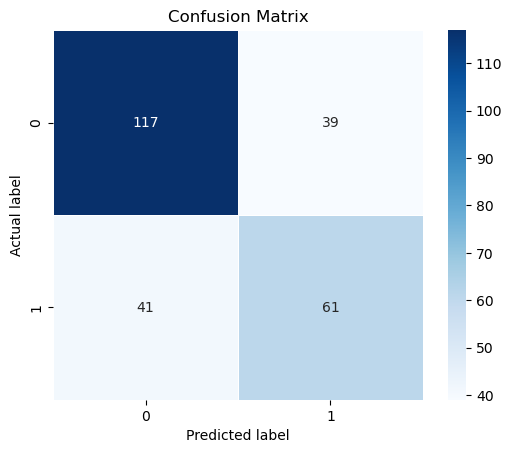

In [113]:
sns.heatmap(cm, annot=True, fmt='d', linewidths=0.5, square=True, cmap='Blues')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.title('Confusion Matrix')
plt.show()

This confusion matrix shows how well the model predicts emotionless and emotional states. The model correctly predcited 117 emotionless instances and 61 emotional instances. However, there were also misclassifications. The model incorrectly predicted 39 emotionless instances as emotional and 41 emotional instances as emotionless. 

These results show that the model preforms better at identifying emotionless states than emotional ones. It correctly classifeis a larger portion of class 0, emotionless. However, the model struggles in detecting emotional states, reflected by the relatively high number of false negatives. This indicates that there is a number of emotional instances that are missed by the model. 

Overall, the model demonstrates moderate prediction ability, but it is more reliable when predicting emotionless states than emotional states. This suggests that while the physiological features used in the model can capture some relationships and patterns in terms of emotion, they are not perfect at fully distinguishing emotional states.

### Classification Report

In [140]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.74      0.75      0.75       156
           1       0.61      0.60      0.60       102

    accuracy                           0.69       258
   macro avg       0.68      0.67      0.67       258
weighted avg       0.69      0.69      0.69       258



The classification report shows that the model performs better at predicting emotionless states than emotional states. For the emotionless class, the model achieved a precision of 0.74, a recall of 0.75 , and an F1-score of 0.75. This indicates that the model is relatively strong and balanced in terms of correctly identifying emotionless instances. On the other, the model performs worse when predicting emotional class with a precision of 0.61, a recall of 0.60, and an F1-score of 0.60. This indicates that the model is less effective at predicting emotional states and misses a portion of them.

The overall accuracy of the model is 0.69, meaning it correctly predicts about 69% of all the observations. The macro average F1-score of 0.67 suggests there is moderate performance across both states, while the weighted average F1-score of 0.69 shows slightly better performance. This is likely due to the fact there are slightly more emotionless observations then emotional observations.

Overall, these results indicate that the model performs better at predicting emotionless states than emotional states. The lower recall and F1-score for emotional class suggests that the model struggles to fully analyze the patterns associated with emotional responses, resulting in missed emotional instances.

# Summary

This project investigated whether physiological signals collected from wearable devices could be used to predict emotional states. A logistic regression model was created using features like electrodermal activity (EDA), temperature, heart rate (HR), blood volume pulse (BVP), interbeat interval (IBI), and accelerometer data. The results show that the model achieved moderate performance. It has an accuracy of around 69% and balanced but lower precision, recall, and F1-scores for the emotional class. Additionaly, the model has an AUC score of 0.72 which indicates it has a good ability to differentiate between emotional and emotionless states.

The model was better at identifying emotionless states than it was at predicting emotional ones, reflected by higher recall and F1-scores for the emotionless class. However, there was a lower recall score for emotional states, indicating that the model missed a number of emotional instances. This suggests that although physiological signals can reflect some patterns and relationships associated with emotional responses, there is still a significant amount of overlap between emotional and emotionless states.

Electrodermal activity and temperature appeared to be the best at predicting emotional state, as it had far more separation between the two classes in the visualizations we created. Other features like BVP, IBI, and accelerometer data added some variability but had weaker relationships with emotional state. In turn, this weakened the overall performance of the model.

These findings are vital for multiple industries. In the healthcare and mental health world, wearable devices could be further developed so they can better be used to monitor emotional states and detect stress or anxiety in real time, allowing for intervention to be made much earlier. From a business and marketing perspective, companies could implement these wearable devices and us the physiological data to better understand consumer emotional responses to their products, advertisements, and other interactions. As a result, they could develop more effective marketing strategies. Furthermore, in a workplace environment as a whole this data and wearable devices could be implemented to improve employee well being.

Overall this project demonstrates that physiological data can be used to predict emotional states, but is limited and its performance indicates there is need for improvement. Future research and development could take place to create more advanced models, further feature engineering, and more descriptive emotion labels to improve prediction accuracy. All of these findings collectively highlight the potential of wearable technology in emotion detection and how if developed properly, it could certainly be implemented in many real world instances. 